# Varmestrålingslab

#### Initialisering

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from feil_analyse import feil_analyse

### Leslies kube

[0.97058824 0.97058824 0.97014925 0.97902098]
[0.36764706 0.38235294 0.37313433 0.38461538]
[0.08823529 0.07843137 0.06716418 0.06993007]


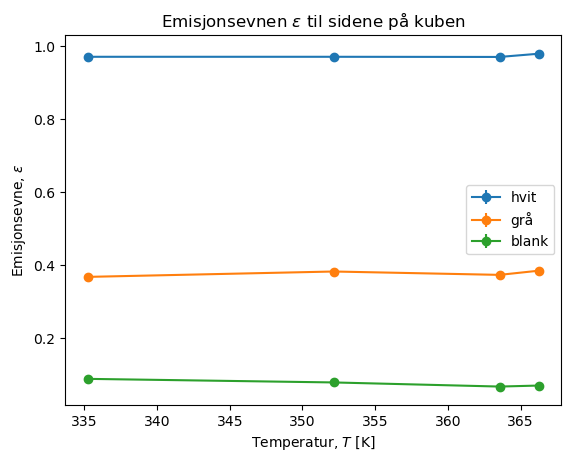

In [2]:
# Konvertering til absolutt temperatur

def T_K(T_C):
    return T_C + 273.15

temperaturer2 = T_K(np.array([62.1, 79, 90.4, 93.1])) # K

hvit_spenning = np.array([6.6, 9.9, 13, 14.0]) # mV
graa_spenning = np.array([2.5, 3.9, 5.0, 5.5]) # mV
blank_spenning = np.array([0.6, 0.8, 0.9, 1.0]) # mV
svart_spenning = np.array([6.8, 10.2, 13.4, 14.3]) # mV


emisjon_hvit = hvit_spenning / svart_spenning
emisjon_graa = graa_spenning / svart_spenning
emisjon_blank = blank_spenning / svart_spenning



# Antatt måleusikkerhet (her absolutt i mV)
usikkerhet_hvit = np.full_like(hvit_spenning, 0.05)   # ±0.5 mV usikkerhet
usikkerhet_graa = np.full_like(graa_spenning, 0.05)
usikkerhet_blank = np.full_like(blank_spenning, 0.05)
usikkerhet_svart = np.full_like(svart_spenning, 0.05)


emisjon_hvit_u = emisjon_hvit * np.sqrt( (usikkerhet_hvit/hvit_spenning)**2 + (usikkerhet_svart/svart_spenning)**2 )
emisjon_graa_u = emisjon_graa * np.sqrt( (usikkerhet_graa/graa_spenning)**2 + (usikkerhet_svart/svart_spenning)**2 )
emisjon_blank_u = emisjon_blank * np.sqrt( (usikkerhet_blank/blank_spenning)**2 + (usikkerhet_svart/svart_spenning)**2 )


print(emisjon_hvit)
print(emisjon_graa)
print(emisjon_blank)

plt.errorbar(temperaturer2, emisjon_hvit, yerr=emisjon_hvit_u, fmt='o-', label="hvit")
plt.errorbar(temperaturer2, emisjon_graa, yerr=emisjon_graa_u, fmt='o-', label="grå")
plt.errorbar(temperaturer2, emisjon_blank, yerr=emisjon_blank_u, fmt='o-', label="blank")

plt.xlabel(r"Temperatur, $T$ [K]")
plt.ylabel(r"Emisjonsevne, $\epsilon$")
plt.title(r"Emisjonsevnen $\epsilon$ til sidene på kuben")
plt.legend()
plt.show()

#plotte intensitet, legge til usikkerhet

### Stefan-Boltzmann-lampe

In [3]:

# Eksperimentelle måleverdier

R_0 = 0.285 # Resistansen til lyspæren ved romtemperatur
alpha = 4.5e-3 # Temperaturkoeffisienten til wolfram
T_0 = T_K(23.3) # Romtemperatur i kelvin


def T_from_R(R, alpha=4.5e-3):
    return T_0 + (R - R_0)/(alpha*R_0)


# Måleserier

spenninger = np.arange(1, 12 + 1) # V
spenninger_målt = np.array([0.2,0.6,1.2,2.2,3.4,4.7,6.2,7.8,9.7,11.5,13.3,15.2])*1e-3 # mV til V
strømmer = np.array([1.034,1.290,1.520,1.732,1.935,2.114,2.277,2.442,2.575,2.727,2.870,3.005]) # A


resistanser = spenninger/strømmer # Ohm

rel_res = resistanser/R_0


temp_tabell = np.array([800, 1200, 1470, 1690, 1830, 2000, 2120, 2250, 2380, 2480, 2550, 2650])
temperaturer_2 = T_from_R(resistanser) # K

print(rel_res)

[ 3.39339645  5.43995648  6.92520776  8.10339938  9.06659413  9.95867151
 10.78673848 11.49474834 12.26366888 12.86678375 13.44825478 14.01173483]


### Plotting

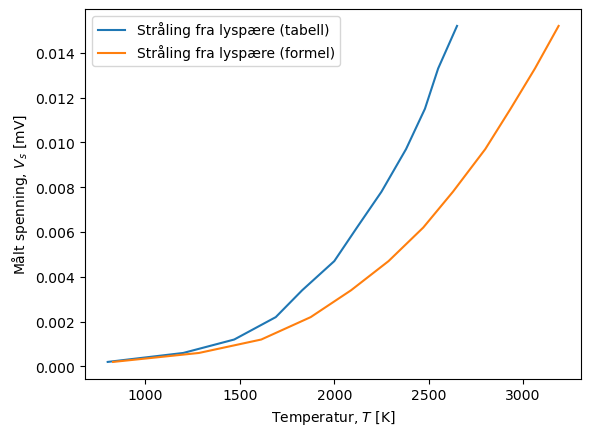

In [4]:

plt.plot(temp_tabell, spenninger_målt, label = 'Stråling fra lyspære (tabell)')
plt.plot(temperaturer_2, spenninger_målt, label = 'Stråling fra lyspære (formel)')
plt.plot()
plt.xlabel(r'Temperatur, $T$ [K]')
plt.ylabel(r'Målt spenning, $V_s$ [mV]')
plt.legend()
plt.show()


### Usikkerhetsberegning

In [5]:

def total_usikkerhet_i_T_glødetråd(T_0I, VI, II, R_1I, R_3I, R_X1I, R_X2I, T_0uI, VuI, IuI, R_1uI, R_3uI, R_X1uI, R_X2uI):
    T_sult = []

    for i in range(len(VI)):


        T0, V, I, R_1, R_3, R_X1, R_X2, alpha = sp.symbols('T0 V I R_1 R_3 R_X1 R_X2 alpha')
        T = T0 + ((V/I) - (R_3/R_1*R_X2 - R_3/R_1*R_X1)) / (alpha * (R_3/R_1*R_X2 - R_3/R_1*R_X1))

        verdier = {
            T0:   T_0I, #Kelvin
            V:     VI[i], #Volt
            I:     II[i], #Amp
            R_1:    R_1I, #Ohm
            R_3:    R_3I, #Ohm
            R_X1:   R_X1I, #Ohm
            R_X2:   R_X2I, #Ohm
            alpha: 4.5e-3 #K^-1
        }

        usikkerheter = {
            T0:   T_0uI,
            V:    VuI,
            I:    IuI,
            R_1:    R_1uI, 
            R_3:    R_3uI, 
            R_X1:   R_X1uI, 
            R_X2:   R_X2uI, 
            alpha:  5e-5
        }
        

        #Gauss feilforplantning
        variable = [T0, V, I, R_1, R_3, R_X1, R_X2]  # kun de med usikkerhet
        partielle = [sp.diff(T, s) for s in variable]

        partielle_evaluert = np.array([sp.N(g.subs(verdier)) for g in partielle])
        usikkerhet_vec = np.array([float(usikkerheter[s]) for s in variable])

        var_T = float(np.sum((partielle_evaluert * usikkerhet_vec)**2)) 
        usikkerhet_T = var_T**0.5

        T_sult.append(usikkerhet_T)

    return T_sult


In [6]:
#målinger i glødetråd eksperiment

R_1 = 1e4
R_3 = 1e2
R_X1 = 4.8 # R_x med kun kabel
R_X2 = 33.3 # R_x med kabel + lyspære


#Usikkerhetene

V_kilde_tråd_usikkerhet = 0.1
I_tråd_usikkerhet = 0.0005
V_sensor_tråd_usikkerhet = 5e-5
T_0_tråd_usikkerhet = 0.05
R_u = 0.002 # usikkerheten i motstandene

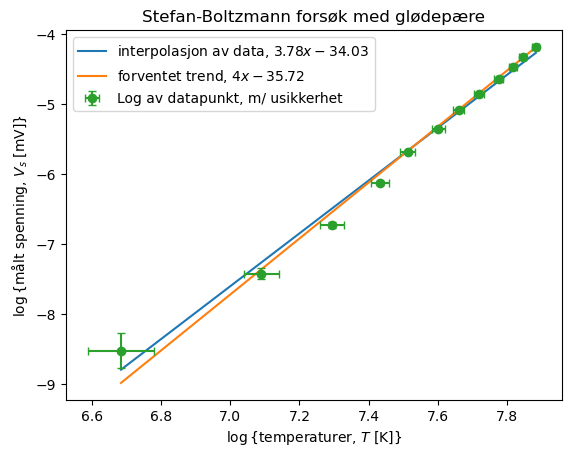

In [7]:

T_u = total_usikkerhet_i_T_glødetråd(T_0, spenninger, strømmer, R_1, R_3, R_X1, R_X2, T_0_tråd_usikkerhet, V_kilde_tråd_usikkerhet, I_tråd_usikkerhet, R_u, R_u, R_u, R_u)

logged_T = np.log(temp_tabell)
logged_T_u = T_u/temp_tabell
logged_V_sens = np.log(spenninger_målt)
logged_v_sens_u = V_sensor_tråd_usikkerhet/spenninger_målt

a, b = np.polyfit( logged_T, logged_V_sens, 1)

a_ex = 4
b_ex = np.mean(logged_V_sens - a_ex * logged_T)

plt.plot(logged_T, a*logged_T + b, label= rf"interpolasjon av data, ${round(a,2)}x {round(b, 2)}$")
plt.plot(logged_T, a_ex*logged_T + b_ex, label= rf"forventet trend, ${round(a_ex,2)}x {round(b_ex, 2)}$")
plt.errorbar(logged_T, logged_V_sens, xerr= logged_T_u, yerr=logged_v_sens_u, fmt='o', capsize=3, label = f"Log av datapunkt, m/ usikkerhet")
plt.axis()
plt.legend()  
plt.xlabel(r"$\log${temperaturer, $T$ [K]}")
plt.ylabel(r"$\log${målt spenning, $V_s$ [mV]}")
plt.title("Stefan-Boltzmann forsøk med glødepære")
plt.show()






In [ ]:
x_axis = temperaturer_2

T0, V, I, R_1, R_3, R_X1, R_X2, alpha = sp.symbols('T0 V I R_1 R_3 R_X1 R_X2 alpha')

T = T0 + ((V/I) - (R_3/R_1*R_X2 - R_3/R_1*R_X1)) / (alpha * (R_3/R_1*R_X2 - R_3/R_1*R_X1))
# verdi_dict{}

uvisse_v = {}


<class 'sympy.core.add.Add'>
